# Feature Engineering - Energy Theft Detection

Notebook này làm 2 việc:

1. Kiểm tra thêm 4 điểm quan trọng sau preprocessing:
   - `inactive` phân bố theo `FLAG`
   - `missing` phân bố theo `FLAG`
   - `outlier` phân bố theo `FLAG`
   - nhóm khách hàng có khả năng phải dùng `global median` để fill

2. Tạo file feature để dùng cho modeling:
   - lấy chuỗi tiêu thụ đã sạch từ `cleaned.csv`
   - merge với tín hiệu dữ liệu thô từ `quality_features.csv`
   - tạo feature thống kê, biến động, xu hướng, recent-vs-past, spike/drop, streak

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Cấu hình đường dẫn

In [13]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CLEANED_PATH = PROCESSED_DIR / "cleaned.csv"
QUALITY_PATH = PROCESSED_DIR / "quality_features.csv"
FEATURE_OUTPUT_PATH = PROCESSED_DIR / "features.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CLEANED_PATH:", CLEANED_PATH)
print("QUALITY_PATH:", QUALITY_PATH)
print("FEATURE_OUTPUT_PATH:", FEATURE_OUTPUT_PATH)

PROJECT_ROOT: d:\CODE\CS114----ML-Project---Energy-Theft-Detection
CLEANED_PATH: d:\CODE\CS114----ML-Project---Energy-Theft-Detection\data\processed\cleaned.csv
QUALITY_PATH: d:\CODE\CS114----ML-Project---Energy-Theft-Detection\data\processed\quality_features.csv
FEATURE_OUTPUT_PATH: d:\CODE\CS114----ML-Project---Energy-Theft-Detection\data\processed\features.csv


## 2. Hàm hỗ trợ

In [14]:
ID_COL = "CONS_NO"
TARGET_COL = "FLAG"

RAW_QUALITY_COLS = {
    "missing_count_raw",
    "missing_ratio_raw",
    "zero_count_raw",
    "zero_ratio_total_raw",
    "zero_ratio_observed_raw",
    "negative_count_raw",
    "negative_ratio_raw",
    "outlier_count_raw",
    "outlier_ratio_raw",
    "max_consumption_raw",
    "max_missing_streak_raw",
    "max_zero_streak_raw",
    "is_inactive_raw",
}


def get_consumption_columns(df: pd.DataFrame) -> list[str]:
    ignored_cols = {ID_COL, TARGET_COL} | RAW_QUALITY_COLS
    candidate_cols = [col for col in df.columns if col not in ignored_cols]

    parsed = []
    for col in candidate_cols:
        date = pd.to_datetime(col, format="%m/%d/%Y", errors="coerce")
        if pd.notna(date):
            parsed.append((col, date))

    parsed.sort(key=lambda x: x[1])
    return [col for col, _ in parsed]


def max_streak_1d(mask: np.ndarray) -> int:
    best = 0
    current = 0

    for value in mask:
        if value:
            current += 1
            best = max(best, current)
        else:
            current = 0

    return best


def max_streak_2d(mask: np.ndarray) -> np.ndarray:
    return np.array([max_streak_1d(row) for row in mask], dtype=np.int16)


def safe_ratio(
    numerator: np.ndarray,
    denominator: np.ndarray,
    eps: float = 1e-6,
    clip_upper: float | None = None,
) -> np.ndarray:
    ratio = numerator / (denominator + eps)

    if clip_upper is not None:
        ratio = np.clip(ratio, 0, clip_upper)

    return ratio


def log_ratio(numerator: np.ndarray, denominator: np.ndarray) -> np.ndarray:
    return np.log1p(numerator) - np.log1p(denominator)


def trend_slope(values: np.ndarray) -> np.ndarray:
    n_days = values.shape[1]
    t = np.arange(n_days, dtype=np.float32)
    t_centered = t - t.mean()
    denom = np.sum(t_centered ** 2)

    return values @ t_centered / denom

## 3. Load dữ liệu

In [15]:
cleaned_df = pd.read_csv(CLEANED_PATH)
quality_df = pd.read_csv(QUALITY_PATH)

consumption_cols = get_consumption_columns(cleaned_df)
dates = pd.to_datetime(consumption_cols, format="%m/%d/%Y")

print("cleaned_df:", cleaned_df.shape)
print("quality_df:", quality_df.shape)
print("Số ngày:", len(consumption_cols))
print("Ngày đầu:", consumption_cols[0])
print("Ngày cuối:", consumption_cols[-1])

display(cleaned_df.head())
display(quality_df.head())

cleaned_df: (42372, 1036)
quality_df: (42372, 15)
Số ngày: 1034
Ngày đầu: 1/1/2014
Ngày cuối: 10/31/2016


,CONS_NO,FLAG,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,...,10/22/2016,10/23/2016,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016
0,0387DD8A07E07FDA6271170F86AD9151,1,0.0,0.0,0.01,0.0,0.0,0.00,0.00,0.00,...,0.02,0.83,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,...,17.83,23.91,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.0,0.0,0.00,0.0,0.0,4.98,9.87,11.29,...,6.49,6.49,6.49,1.43,2.22,2.41,3.48,2.89,1.88,1.16
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,...,19.96,19.50,20.98,18.47,15.50,14.80,19.28,16.10,17.51,16.67
4,EDFC78B07BA2908B3395C4EB2304665E,1,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.00,...,2.14,2.59,0.61,1.33,0.55,1.62,1.53,2.10,1.16,2.13


,CONS_NO,FLAG,missing_count_raw,missing_ratio_raw,zero_count_raw,zero_ratio_total_raw,zero_ratio_observed_raw,negative_count_raw,negative_ratio_raw,outlier_count_raw,outlier_ratio_raw,max_consumption_raw,max_missing_streak_raw,max_zero_streak_raw,is_inactive_raw
0,0387DD8A07E07FDA6271170F86AD9151,1,4,0.003868,862,0.833656,0.836893,0,0.0,0,0.0,18.29,2,374,1
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,188,0.181818,50,0.048356,0.059102,0,0.0,0,0.0,44.57,158,50,0
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,320,0.309478,34,0.032882,0.047619,0,0.0,0,0.0,79.71,28,12,0
3,B32AC8CC6D5D805AC053557AB05F5343,1,17,0.016441,797,0.770793,0.783677,0,0.0,0,0.0,40.98,6,372,0
4,EDFC78B07BA2908B3395C4EB2304665E,1,679,0.656673,38,0.036750,0.107042,0,0.0,0,0.0,399.40,676,35,0


# Phần A - Kiểm tra thêm sau preprocessing

## A1. Inactive phân bố theo FLAG

Kết quả kỳ vọng từ lần chạy trước:
- Normal inactive rate khoảng `5.99%`
- Theft inactive rate khoảng `1.05%`

Điều này nghĩa là `is_inactive_raw` **không phải dấu hiệu theft trực tiếp**. Nó vẫn nên giữ lại, nhưng không nên diễn giải là cứ inactive thì theft.

,n_customers,n_inactive,inactive_rate
FLAG,,,
0,38757,2322,0.059912
1,3615,38,0.010512


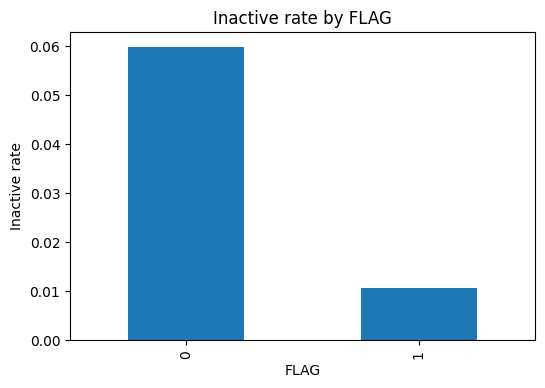

In [16]:
inactive_summary = (
    quality_df
    .groupby(TARGET_COL)["is_inactive_raw"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_customers", "sum": "n_inactive", "mean": "inactive_rate"})
)

display(inactive_summary)

ax = inactive_summary["inactive_rate"].plot(kind="bar", figsize=(6, 4), title="Inactive rate by FLAG")
ax.set_xlabel("FLAG")
ax.set_ylabel("Inactive rate")
plt.show()

## A2. Missing phân bố theo FLAG

Kết quả kỳ vọng từ lần chạy trước:
- Normal missing mean khoảng `25.10%`
- Theft missing mean khoảng `31.47%`
- Median theft cũng cao hơn median normal.

Điều này cho thấy missing có thể là tín hiệu liên quan đến theft, nên các feature missing cần được giữ lại.

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38757.0,0.250962,0.287227,0.000967,0.012573,0.092843,0.579304,1.0
1,3615.0,0.314687,0.292858,0.000967,0.022244,0.213733,0.705996,1.0


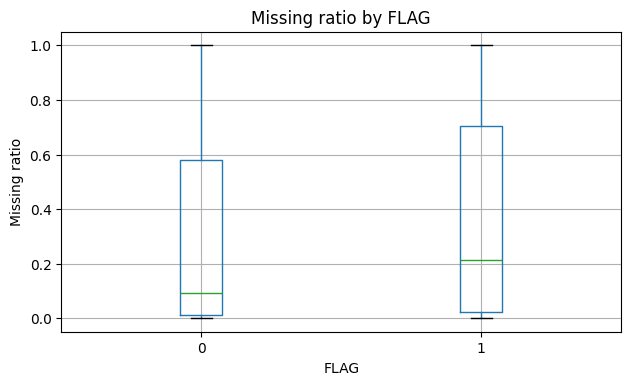

In [17]:
missing_summary = quality_df.groupby(TARGET_COL)["missing_ratio_raw"].describe()
display(missing_summary)

ax = quality_df.boxplot(
    column="missing_ratio_raw",
    by=TARGET_COL,
    figsize=(7, 4)
)
ax.set_title("Missing ratio by FLAG")
ax.set_xlabel("FLAG")
ax.set_ylabel("Missing ratio")
plt.suptitle("")
plt.show()

## A3. Outlier phân bố theo FLAG

Kết quả kỳ vọng từ lần chạy trước:
- Normal có outlier rate khoảng `1.25%`
- Theft có outlier rate khoảng `2.93%`
- Theft có số outlier trung bình cao hơn normal.

Vì outlier đã bị clip trong `cleaned.csv`, các feature outlier raw cần được merge từ `quality_features.csv`.

outlier_count_raw                                                   \
                 count      mean        std  min  25%  50%  75%     max   
FLAG                                                                      
0              38757.0  0.151715   8.079751  0.0  0.0  0.0  0.0   952.0   
1               3615.0  4.201936  45.492188  0.0  0.0  0.0  0.0  1021.0   

     outlier_ratio_raw            ...                max_consumption_raw  \
                 count      mean  ...  75%       max               count   
FLAG                              ...                                      
0              38757.0  0.000147  ...  0.0  0.920696             38755.0   
1               3615.0  0.004064  ...  0.0  0.987427              3612.0   

                                                                      
            mean           std  min     25%    50%    75%        max  
FLAG                                                                  
0     137.410047   6809.339023  0.0  10.340  22.03  35.65  800003.32  
1     427.927510  11722.617595  0.0  22.255  38.05  66.11  514991.78  

[2 rows x 24 columns]

,n_customers,n_has_outlier,has_outlier_rate
FLAG,,,
0,38757,485,0.012514
1,3615,106,0.029322


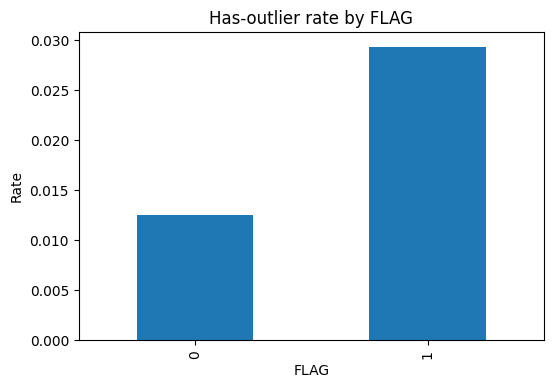

In [18]:
outlier_summary = quality_df.groupby(TARGET_COL)[
    ["outlier_count_raw", "outlier_ratio_raw", "max_consumption_raw"]
].describe()

display(outlier_summary)

outlier_customer_rate = (
    quality_df
    .assign(has_outlier_raw=(quality_df["outlier_count_raw"] > 0).astype(int))
    .groupby(TARGET_COL)["has_outlier_raw"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_customers", "sum": "n_has_outlier", "mean": "has_outlier_rate"})
)

display(outlier_customer_rate)

ax = outlier_customer_rate["has_outlier_rate"].plot(kind="bar", figsize=(6, 4), title="Has-outlier rate by FLAG")
ax.set_xlabel("FLAG")
ax.set_ylabel("Rate")
plt.show()

## A4. Nhóm toàn missing raw

Kết quả kỳ vọng từ lần chạy trước:
- Có 5 khách hàng có toàn bộ 1,034 ngày đều missing.
- Tương ứng đúng 5,170 ô còn lại trước khi dùng global median.
- Nhóm này gồm cả normal và theft.

Vì chuỗi sau fill của nhóm này là nhân tạo, cần tạo `is_all_missing_raw` để model biết đây là trường hợp đặc biệt.

In [19]:
n_days = len(consumption_cols)

global_median_candidates = quality_df[quality_df["missing_count_raw"] == n_days].copy()

print("Số ngày:", n_days)
print("Số khách hàng có toàn bộ consumption raw là NaN:", len(global_median_candidates))
print("Số ô tương ứng:", len(global_median_candidates) * n_days)

display(
    global_median_candidates[
        [
            ID_COL,
            TARGET_COL,
            "missing_count_raw",
            "missing_ratio_raw",
            "zero_count_raw",
            "outlier_count_raw",
            "max_consumption_raw",
        ]
    ]
)

display(global_median_candidates[TARGET_COL].value_counts(dropna=False))

Số ngày: 1034
Số khách hàng có toàn bộ consumption raw là NaN: 5
Số ô tương ứng: 5170


,CONS_NO,FLAG,missing_count_raw,missing_ratio_raw,zero_count_raw,outlier_count_raw,max_consumption_raw
26036,1DA20B5F8ACE6E379E9E1E643DE651A3,1,1034,1.0,0,0,NaN
26154,F74C879345037BF76351523FDECC8C75,1,1034,1.0,0,0,NaN
27117,A66225A1159051F45EF22E54897C6413,1,1034,1.0,0,0,NaN
40593,BE4A628418F6C8E07C549FDF6654F910,0,1034,1.0,0,0,NaN
42225,3BA357452769415BE04F5931D15B023B,0,1034,1.0,0,0,NaN


FLAG
1    3
0    2
Name: count, dtype: int64

# Kết luận phần A

Các điều chỉnh cho phần B:

1. Giữ `is_inactive_raw`, nhưng xem nó là tín hiệu trạng thái công tơ, không phải theft signal trực tiếp.
2. Tăng độ rõ của nhóm missing bằng các feature:
   - `is_high_missing_raw`
   - `is_very_high_missing_raw`
   - `is_all_missing_raw`
3. Giữ outlier raw và thêm:
   - `has_outlier_raw`
   - `log1p_outlier_count_raw`
   - `log1p_max_consumption_raw`
4. Với các ratio temporal, dùng thêm `log-ratio` và clip ratio để tránh giá trị cực lớn khi mẫu số gần 0.

# Phần B - Feature Engineering

Các feature được chia thành 5 nhóm:

1. **Quality features**: lấy từ dữ liệu raw trước khi clean.
2. **Statistical features**: mean, median, std, min, max, quantile, IQR, CV.
3. **Temporal features**: recent mean, past mean, recent-vs-past ratio, trend slope.
4. **Volatility features**: mức thay đổi ngày qua ngày, spike/drop.
5. **Streak/behavior features**: chuỗi zero, chuỗi tiêu thụ thấp, tỷ lệ ngày thấp.

Điểm quan trọng: `quality_features.csv` được merge vào feature cuối, vì 4 kiểm tra ở trên chính là nguồn tín hiệu quan trọng cho model.

## B1. Statistical features

Nhóm này mô tả mức tiêu thụ tổng quát. Vì dữ liệu skew mạnh, thêm cả log-transform của một số thống kê.

In [20]:
X = cleaned_df[consumption_cols].to_numpy(dtype=np.float32)
X_log = np.log1p(X)

features = cleaned_df[[ID_COL, TARGET_COL]].copy()

features["mean_consumption"] = X.mean(axis=1)
features["median_consumption"] = np.median(X, axis=1)
features["std_consumption"] = X.std(axis=1)
features["min_consumption"] = X.min(axis=1)
features["max_consumption"] = X.max(axis=1)
features["sum_consumption"] = X.sum(axis=1)

q25 = np.percentile(X, 25, axis=1)
q75 = np.percentile(X, 75, axis=1)
q90 = np.percentile(X, 90, axis=1)
q95 = np.percentile(X, 95, axis=1)

features["q25_consumption"] = q25
features["q75_consumption"] = q75
features["q90_consumption"] = q90
features["q95_consumption"] = q95
features["iqr_consumption"] = q75 - q25
features["range_consumption"] = features["max_consumption"] - features["min_consumption"]
features["cv_consumption"] = safe_ratio(
    features["std_consumption"].to_numpy(),
    features["mean_consumption"].to_numpy(),
    clip_upper=50,
)

features["mean_log1p_consumption"] = X_log.mean(axis=1)
features["std_log1p_consumption"] = X_log.std(axis=1)
features["max_log1p_consumption"] = X_log.max(axis=1)

display(features.head())

,CONS_NO,FLAG,mean_consumption,median_consumption,std_consumption,min_consumption,max_consumption,sum_consumption,q25_consumption,q75_consumption,q90_consumption,q95_consumption,iqr_consumption,range_consumption,cv_consumption,mean_log1p_consumption,std_log1p_consumption,max_log1p_consumption
0,0387DD8A07E07FDA6271170F86AD9151,1,0.951103,0.000000,3.100520,0.0,18.290001,983.440369,0.000000,0.000000,1.687000,9.704000,0.0000,18.290001,3.259917,0.240291,0.683428,2.959587
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,4.100145,1.060000,6.608953,0.0,44.570000,4239.550293,0.430000,4.807500,15.261001,18.910500,4.3775,44.570000,1.611882,1.083470,0.944236,3.819250
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,10.036695,7.275000,11.302323,0.0,79.709999,10377.942383,2.585000,12.507500,22.110001,34.902500,9.9225,79.709999,1.126100,1.953309,0.999732,4.390862
3,B32AC8CC6D5D805AC053557AB05F5343,1,3.786829,0.000000,8.056552,0.0,40.980000,3915.580811,0.000000,0.000000,15.032000,23.593500,0.0000,40.980000,2.127519,0.628628,1.180195,3.737193
4,EDFC78B07BA2908B3395C4EB2304665E,1,61.553967,54.630001,40.909782,0.0,399.399994,63646.800781,54.630001,54.630001,111.889000,150.623505,0.0000,399.399994,0.664617,3.815714,1.106912,5.992464


## B2. Zero và low-consumption features

Dù `inactive` nghiêng về normal, zero/low pattern vẫn hữu ích để phân biệt nhiều kiểu hành vi khác nhau.

In [21]:
LOW_CONSUMPTION_THRESHOLD = 1.0

zero_mask_clean = X == 0
low_mask_clean = X <= LOW_CONSUMPTION_THRESHOLD

features["zero_count_clean"] = zero_mask_clean.sum(axis=1)
features["zero_ratio_clean"] = zero_mask_clean.mean(axis=1)

features["low_consumption_count"] = low_mask_clean.sum(axis=1)
features["low_consumption_ratio"] = low_mask_clean.mean(axis=1)

features["max_zero_streak_clean"] = max_streak_2d(zero_mask_clean)
features["max_low_streak_clean"] = max_streak_2d(low_mask_clean)

display(features[
    [
        ID_COL,
        TARGET_COL,
        "zero_ratio_clean",
        "low_consumption_ratio",
        "max_zero_streak_clean",
        "max_low_streak_clean",
    ]
].head())

,CONS_NO,FLAG,zero_ratio_clean,low_consumption_ratio,max_zero_streak_clean,max_low_streak_clean
0,0387DD8A07E07FDA6271170F86AD9151,1,0.836557,0.893617,553,657
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.058027,0.443907,60,254
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.047389,0.164410,23,33
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.773694,0.773694,800,800
4,EDFC78B07BA2908B3395C4EB2304665E,1,0.036750,0.053191,35,42


## B3. Temporal features

Ở bản trước, các ratio như `recent30_to_first90_ratio` có thể rất lớn khi `first_90_mean` gần 0.  
Bản này giữ ratio nhưng có clip, đồng thời thêm `log-ratio` ổn định hơn.

In [22]:
def window_mean(values: np.ndarray, n_recent_days: int) -> np.ndarray:
    n_recent_days = min(n_recent_days, values.shape[1])
    return values[:, -n_recent_days:].mean(axis=1)


features["first_30_mean"] = X[:, :30].mean(axis=1)
features["first_90_mean"] = X[:, :90].mean(axis=1)

features["recent_30_mean"] = window_mean(X, 30)
features["recent_90_mean"] = window_mean(X, 90)
features["recent_180_mean"] = window_mean(X, 180)

mid = X.shape[1] // 2
features["first_half_mean"] = X[:, :mid].mean(axis=1)
features["second_half_mean"] = X[:, mid:].mean(axis=1)

features["recent30_to_first90_ratio"] = safe_ratio(
    features["recent_30_mean"].to_numpy(),
    features["first_90_mean"].to_numpy(),
    clip_upper=50,
)

features["second_half_to_first_half_ratio"] = safe_ratio(
    features["second_half_mean"].to_numpy(),
    features["first_half_mean"].to_numpy(),
    clip_upper=50,
)

features["recent30_first90_log_ratio"] = log_ratio(
    features["recent_30_mean"].to_numpy(),
    features["first_90_mean"].to_numpy(),
)

features["second_first_half_log_ratio"] = log_ratio(
    features["second_half_mean"].to_numpy(),
    features["first_half_mean"].to_numpy(),
)

features["recent30_minus_first90"] = (
    features["recent_30_mean"] - features["first_90_mean"]
)

features["second_half_minus_first_half"] = (
    features["second_half_mean"] - features["first_half_mean"]
)

features["trend_slope"] = trend_slope(X)

display(features[
    [
        ID_COL,
        TARGET_COL,
        "recent_30_mean",
        "first_90_mean",
        "recent30_to_first90_ratio",
        "recent30_first90_log_ratio",
        "trend_slope",
    ]
].head())

,CONS_NO,FLAG,recent_30_mean,first_90_mean,recent30_to_first90_ratio,recent30_first90_log_ratio,trend_slope
0,0387DD8A07E07FDA6271170F86AD9151,1,0.361000,0.000111,50.000000,0.308109,-0.001932
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,16.795332,0.111111,50.000000,2.773576,0.015815
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,5.491333,7.270335,0.755307,-0.242207,-0.000968
3,B32AC8CC6D5D805AC053557AB05F5343,1,16.716667,0.000000,50.000000,2.874506,0.017747
4,EDFC78B07BA2908B3395C4EB2304665E,1,1.459333,79.233459,0.018418,-3.485050,0.009414


## B4. Volatility, spike và drop features

Spike/drop giúp bắt các thay đổi đột ngột.  
Với theft detection, drop mạnh kéo dài thường đáng chú ý hơn chỉ nhìn mean.

In [23]:
ABS_CHANGE_THRESHOLD = 5.0
REL_CHANGE_THRESHOLD = 0.5

prev = X[:, :-1]
nxt = X[:, 1:]

diff = nxt - prev
abs_diff = np.abs(diff)

features["mean_daily_change"] = diff.mean(axis=1)
features["mean_abs_daily_change"] = abs_diff.mean(axis=1)
features["max_abs_daily_change"] = abs_diff.max(axis=1)
features["std_daily_change"] = diff.std(axis=1)

spike_mask = (
    (diff >= ABS_CHANGE_THRESHOLD)
    & (diff >= REL_CHANGE_THRESHOLD * np.maximum(prev, 1.0))
)

drop_mask = (
    (diff <= -ABS_CHANGE_THRESHOLD)
    & (-diff >= REL_CHANGE_THRESHOLD * np.maximum(prev, 1.0))
)

features["spike_count"] = spike_mask.sum(axis=1)
features["spike_ratio"] = spike_mask.mean(axis=1)
features["drop_count"] = drop_mask.sum(axis=1)
features["drop_ratio"] = drop_mask.mean(axis=1)

features["max_spike_streak"] = max_streak_2d(spike_mask)
features["max_drop_streak"] = max_streak_2d(drop_mask)

features["drop_to_spike_ratio"] = safe_ratio(
    features["drop_count"].to_numpy(),
    features["spike_count"].to_numpy(),
    clip_upper=50,
)

display(features[
    [
        ID_COL,
        TARGET_COL,
        "mean_abs_daily_change",
        "max_abs_daily_change",
        "spike_count",
        "drop_count",
        "drop_to_spike_ratio",
    ]
].head())

,CONS_NO,FLAG,mean_abs_daily_change,max_abs_daily_change,spike_count,drop_count,drop_to_spike_ratio
0,0387DD8A07E07FDA6271170F86AD9151,1,0.222314,10.270000,3,3,1.000000
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.561297,30.129999,6,0,0.000000
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,2.265344,79.709999,59,44,0.745763
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.500087,13.999999,5,1,0.200000
4,EDFC78B07BA2908B3395C4EB2304665E,1,4.234878,351.380005,10,6,0.600000


## B5. Monthly features

Nhóm này giữ seasonality theo tháng. Nếu tiêu thụ thay đổi theo mùa, các feature này có thể hữu ích.

In [24]:
month_values = dates.month

for month in range(1, 13):
    month_mask = month_values == month
    if month_mask.sum() > 0:
        features[f"month_{month:02d}_mean"] = X[:, month_mask].mean(axis=1)
        features[f"month_{month:02d}_std"] = X[:, month_mask].std(axis=1)

monthly_mean_cols = [
    f"month_{month:02d}_mean"
    for month in range(1, 13)
    if f"month_{month:02d}_mean" in features.columns
]

features["monthly_mean_range"] = (
    features[monthly_mean_cols].max(axis=1)
    - features[monthly_mean_cols].min(axis=1)
)

features["monthly_mean_std"] = features[monthly_mean_cols].std(axis=1)

display(features[[ID_COL, TARGET_COL, "monthly_mean_range", "monthly_mean_std"] + monthly_mean_cols[:3]].head())

,CONS_NO,FLAG,monthly_mean_range,monthly_mean_std,month_01_mean,month_02_mean,month_03_mean
0,0387DD8A07E07FDA6271170F86AD9151,1,4.228871,1.651140,1.556774,0.000000,0.000000
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,7.947212,2.637339,1.657849,1.916823,1.974409
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,15.870776,4.954076,5.689032,7.993648,10.932255
3,B32AC8CC6D5D805AC053557AB05F5343,1,9.145054,3.366558,0.000000,0.000000,1.990000
4,EDFC78B07BA2908B3395C4EB2304665E,1,48.556553,17.830633,38.467960,75.955956,77.619637


## B5.1. Rolling window features

Nhóm này mô tả hành vi tiêu thụ trong các cửa sổ thời gian ngắn hơn như 7 ngày, 30 ngày, 90 ngày.

Các feature thống kê tổng quát như `mean_consumption`, `std_consumption` chỉ nhìn toàn bộ chuỗi. Tuy nhiên, trong theft detection, hành vi bất thường có thể chỉ xảy ra trong một giai đoạn ngắn. Vì vậy rolling feature giúp model nhìn được:

- Trung bình tiêu thụ cục bộ có ổn định không.
- Có giai đoạn nào tiêu thụ tăng/giảm mạnh không.
- Độ dao động trong từng cửa sổ thời gian có cao không.

Ví dụ:
- `roll30_mean_min`: mức trung bình 30 ngày thấp nhất trong toàn bộ chuỗi.
- `roll30_mean_max`: mức trung bình 30 ngày cao nhất trong toàn bộ chuỗi.
- `roll30_std_avg`: độ dao động trung bình trong các cửa sổ 30 ngày.
- `roll30_std_max`: cửa sổ 30 ngày dao động mạnh nhất.

Nhóm này hữu ích vì nó bắt được bất thường theo giai đoạn, không chỉ nhìn toàn bộ lịch sử.

In [25]:
def rolling_mean_2d(values: np.ndarray, window: int) -> np.ndarray:

    values = values.astype(np.float64)

    padded_cumsum = np.concatenate(
        [np.zeros((values.shape[0], 1)), np.cumsum(values, axis=1)],
        axis=1,
    )

    window_sum = padded_cumsum[:, window:] - padded_cumsum[:, :-window]
    rolling_mean = window_sum / window

    return rolling_mean


def rolling_std_2d(values: np.ndarray, window: int) -> np.ndarray:
  
    values = values.astype(np.float64)

    rolling_mean = rolling_mean_2d(values, window)
    rolling_mean_square = rolling_mean_2d(values ** 2, window)

    rolling_var = rolling_mean_square - rolling_mean ** 2
    rolling_var = np.maximum(rolling_var, 0)

    rolling_std = np.sqrt(rolling_var)

    return rolling_std


ROLLING_WINDOWS = [7, 30, 90]

for window in ROLLING_WINDOWS:
    roll_mean = rolling_mean_2d(X, window)
    roll_std = rolling_std_2d(X, window)

    features[f"roll{window}_mean_avg"] = roll_mean.mean(axis=1)
    features[f"roll{window}_mean_std"] = roll_mean.std(axis=1)
    features[f"roll{window}_mean_min"] = roll_mean.min(axis=1)
    features[f"roll{window}_mean_max"] = roll_mean.max(axis=1)
    features[f"roll{window}_mean_range"] = roll_mean.max(axis=1) - roll_mean.min(axis=1)

    features[f"roll{window}_std_avg"] = roll_std.mean(axis=1)
    features[f"roll{window}_std_max"] = roll_std.max(axis=1)

    features[f"roll{window}_max_to_avg_ratio"] = safe_ratio(
        roll_mean.max(axis=1),
        roll_mean.mean(axis=1),
        clip_upper=50,
    )

display(
    features[
        [
            ID_COL,
            TARGET_COL,
            "roll7_mean_avg",
            "roll30_mean_avg",
            "roll30_mean_range",
            "roll30_std_avg",
            "roll90_mean_range",
            "roll90_std_max",
        ]
    ].head()
)

,CONS_NO,FLAG,roll7_mean_avg,roll30_mean_avg,roll30_mean_range,roll30_std_avg,roll90_mean_range,roll90_std_max
0,0387DD8A07E07FDA6271170F86AD9151,1,0.955268,0.973043,12.622000,0.564990,9.049444,6.417900
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,4.075400,3.976011,24.629000,0.983448,19.200555,7.120859
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,10.088262,10.179469,46.310000,5.083627,33.139333,23.462978
3,B32AC8CC6D5D805AC053557AB05F5343,1,3.759610,3.653914,32.509333,0.853442,24.879667,10.074594
4,EDFC78B07BA2908B3395C4EB2304665E,1,61.908277,63.308108,181.984999,10.340286,85.930334,95.736944


## B5.2. Segment features

Nhóm này chia toàn bộ chuỗi tiêu thụ thành nhiều đoạn lớn bằng nhau, ví dụ 4 đoạn.

Mục tiêu là xem hành vi tiêu thụ có thay đổi theo từng giai đoạn không.

So với `first_half_mean` và `second_half_mean`, segment feature chi tiết hơn vì nó chia thành 4 phần thay vì chỉ 2 phần.

Ví dụ:
- `segment_1_mean`: trung bình tiêu thụ ở giai đoạn đầu.
- `segment_4_mean`: trung bình tiêu thụ ở giai đoạn cuối.
- `segment4_to_segment1_ratio`: giai đoạn cuối so với giai đoạn đầu.
- `segment_mean_range`: mức chênh lệch giữa giai đoạn cao nhất và thấp nhất.
- `segment_largest_drop`: mức giảm mạnh nhất giữa hai giai đoạn liên tiếp.

Nhóm này hữu ích nếu hành vi bất thường xảy ra theo từng giai đoạn, ví dụ sau một thời điểm nào đó tiêu thụ giảm rõ rệt.

In [26]:
N_SEGMENTS = 4

segments = np.array_split(X, N_SEGMENTS, axis=1)

segment_means = []
segment_stds = []

for idx, segment in enumerate(segments, start=1):
    seg_mean = segment.mean(axis=1)
    seg_std = segment.std(axis=1)

    features[f"segment_{idx}_mean"] = seg_mean
    features[f"segment_{idx}_std"] = seg_std

    segment_means.append(seg_mean)
    segment_stds.append(seg_std)

segment_means = np.vstack(segment_means).T
segment_stds = np.vstack(segment_stds).T

features["segment_mean_range"] = segment_means.max(axis=1) - segment_means.min(axis=1)
features["segment_mean_std"] = segment_means.std(axis=1)

features["segment4_to_segment1_ratio"] = safe_ratio(
    features["segment_4_mean"].to_numpy(),
    features["segment_1_mean"].to_numpy(),
    clip_upper=50,
)

features["segment4_segment1_log_ratio"] = log_ratio(
    features["segment_4_mean"].to_numpy(),
    features["segment_1_mean"].to_numpy(),
)

features["segment4_minus_segment1"] = (
    features["segment_4_mean"] - features["segment_1_mean"]
)

segment_diffs = np.diff(segment_means, axis=1)

features["segment_largest_drop"] = segment_diffs.min(axis=1)
features["segment_largest_increase"] = segment_diffs.max(axis=1)
features["n_segment_drops"] = (segment_diffs < 0).sum(axis=1)
features["n_segment_increases"] = (segment_diffs > 0).sum(axis=1)

display(
    features[
        [
            ID_COL,
            TARGET_COL,
            "segment_1_mean",
            "segment_2_mean",
            "segment_3_mean",
            "segment_4_mean",
            "segment4_to_segment1_ratio",
            "segment_largest_drop",
        ]
    ].head()
)

C:\Users\callm\AppData\Local\Temp\ipykernel_238608\1952353572.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f"segment_{idx}_mean"] = seg_mean
C:\Users\callm\AppData\Local\Temp\ipykernel_238608\1952353572.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[f"segment_{idx}_std"] = seg_std
C:\Users\callm\AppData\Local\Temp\ipykernel_238608\1952353572.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Cons

,CONS_NO,FLAG,segment_1_mean,segment_2_mean,segment_3_mean,segment_4_mean,segment4_to_segment1_ratio,segment_largest_drop
0,0387DD8A07E07FDA6271170F86AD9151,1,0.000077,3.729344,0.000000,0.067907,50.000000,-3.729344
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.631081,0.484710,2.014804,13.297442,21.070860,-0.146371
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,6.949340,12.889438,12.827516,7.481356,1.076556,-5.346160
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.000000,0.000000,0.000000,15.176670,50.000000,0.000000
4,EDFC78B07BA2908B3395C4EB2304665E,1,63.179390,54.629902,55.852249,72.574463,1.148705,-8.549488


## B5.3. Weekday / weekend features

Nhóm này so sánh tiêu thụ điện giữa ngày thường và cuối tuần.

Một số khách hàng có hành vi tiêu thụ khác nhau giữa weekday và weekend. Ví dụ hộ gia đình có thể dùng điện nhiều hơn vào cuối tuần, còn một số cơ sở kinh doanh có thể dùng điện nhiều hơn vào ngày thường.

Các feature gồm:
- `weekday_mean`: tiêu thụ trung bình ngày thường.
- `weekend_mean`: tiêu thụ trung bình cuối tuần.
- `weekend_to_weekday_ratio`: cuối tuần dùng nhiều hơn hay ít hơn ngày thường.
- `weekend_minus_weekday`: chênh lệch tuyệt đối giữa weekend và weekday.

Nhóm này không phải feature mạnh nhất, nhưng có thể giúp model bắt thêm pattern lịch sinh hoạt.

In [27]:
day_of_week = dates.dayofweek

weekday_mask = day_of_week < 5
weekend_mask = day_of_week >= 5

X_weekday = X[:, weekday_mask]
X_weekend = X[:, weekend_mask]

features["weekday_mean"] = X_weekday.mean(axis=1)
features["weekday_std"] = X_weekday.std(axis=1)

features["weekend_mean"] = X_weekend.mean(axis=1)
features["weekend_std"] = X_weekend.std(axis=1)

features["weekend_to_weekday_ratio"] = safe_ratio(
    features["weekend_mean"].to_numpy(),
    features["weekday_mean"].to_numpy(),
    clip_upper=50,
)

features["weekend_weekday_log_ratio"] = log_ratio(
    features["weekend_mean"].to_numpy(),
    features["weekday_mean"].to_numpy(),
)

features["weekend_minus_weekday"] = (
    features["weekend_mean"] - features["weekday_mean"]
)

features["weekend_std_to_weekday_std_ratio"] = safe_ratio(
    features["weekend_std"].to_numpy(),
    features["weekday_std"].to_numpy(),
    clip_upper=50,
)

display(
    features[
        [
            ID_COL,
            TARGET_COL,
            "weekday_mean",
            "weekend_mean",
            "weekend_to_weekday_ratio",
            "weekend_minus_weekday",
            "weekend_std_to_weekday_std_ratio",
        ]
    ].head()
)

C:\Users\callm\AppData\Local\Temp\ipykernel_238608\1115825249.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["weekday_mean"] = X_weekday.mean(axis=1)
C:\Users\callm\AppData\Local\Temp\ipykernel_238608\1115825249.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["weekday_std"] = X_weekday.std(axis=1)
C:\Users\callm\AppData\Local\Temp\ipykernel_238608\1115825249.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

,CONS_NO,FLAG,weekday_mean,weekend_mean,weekend_to_weekday_ratio,weekend_minus_weekday,weekend_std_to_weekday_std_ratio
0,0387DD8A07E07FDA6271170F86AD9151,1,0.939364,0.980508,1.043798,0.041144,1.017132
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,4.075196,4.162643,1.021458,0.087447,0.986115
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,9.644037,11.020337,1.142710,1.376300,1.114558
3,B32AC8CC6D5D805AC053557AB05F5343,1,3.700217,4.003796,1.082043,0.303579,1.053311
4,EDFC78B07BA2908B3395C4EB2304665E,1,61.432404,61.858913,1.006943,0.426510,1.059218


## B6. Merge và điều chỉnh quality features

Phần này đưa kết quả phần A vào feature cuối:
- `is_inactive_raw`: giữ lại, nhưng không xem là theft signal trực tiếp.
- `missing_*`: giữ kỹ vì theft có missing cao hơn.
- `outlier_*`: giữ kỹ vì theft có outlier rate cao hơn.
- `is_all_missing_raw`: đánh dấu 5 khách hàng toàn missing raw.
- `max_consumption_raw_missing`: đánh dấu trường hợp `max_consumption_raw` bị NaN.

In [28]:
quality_to_merge = quality_df.copy()

quality_to_merge["is_all_missing_raw"] = (
    quality_to_merge["missing_count_raw"] == len(consumption_cols)
).astype(np.int8)

quality_to_merge["is_high_missing_raw"] = (
    quality_to_merge["missing_ratio_raw"] >= 0.50
).astype(np.int8)

quality_to_merge["is_very_high_missing_raw"] = (
    quality_to_merge["missing_ratio_raw"] >= 0.80
).astype(np.int8)

quality_to_merge["has_outlier_raw"] = (
    quality_to_merge["outlier_count_raw"] > 0
).astype(np.int8)

quality_to_merge["max_consumption_raw_missing"] = (
    quality_to_merge["max_consumption_raw"].isna()
).astype(np.int8)

quality_to_merge["max_consumption_raw"] = quality_to_merge["max_consumption_raw"].fillna(0)

quality_to_merge["log1p_outlier_count_raw"] = np.log1p(quality_to_merge["outlier_count_raw"])
quality_to_merge["log1p_max_consumption_raw"] = np.log1p(quality_to_merge["max_consumption_raw"])
quality_to_merge["log1p_missing_count_raw"] = np.log1p(quality_to_merge["missing_count_raw"])
quality_to_merge["log1p_zero_count_raw"] = np.log1p(quality_to_merge["zero_count_raw"])

quality_feature_cols = [col for col in quality_to_merge.columns if col != TARGET_COL]

features = features.merge(
    quality_to_merge[quality_feature_cols],
    on=ID_COL,
    how="left",
)

print("Feature shape sau khi merge:", features.shape)
display(features.head())

Feature shape sau khi merge: (42372, 146)


,CONS_NO,FLAG,mean_consumption,median_consumption,std_consumption,min_consumption,max_consumption,sum_consumption,q25_consumption,q75_consumption,...,is_inactive_raw,is_all_missing_raw,is_high_missing_raw,is_very_high_missing_raw,has_outlier_raw,max_consumption_raw_missing,log1p_outlier_count_raw,log1p_max_consumption_raw,log1p_missing_count_raw,log1p_zero_count_raw
0,0387DD8A07E07FDA6271170F86AD9151,1,0.951103,0.000000,3.100520,0.0,18.290001,983.440369,0.000000,0.000000,...,1,0,0,0,0,0,0.0,2.959587,1.609438,6.760415
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,4.100145,1.060000,6.608953,0.0,44.570000,4239.550293,0.430000,4.807500,...,0,0,0,0,0,0,0.0,3.819250,5.241747,3.931826
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,10.036695,7.275000,11.302323,0.0,79.709999,10377.942383,2.585000,12.507500,...,0,0,0,0,0,0,0.0,4.390862,5.771441,3.555348
3,B32AC8CC6D5D805AC053557AB05F5343,1,3.786829,0.000000,8.056552,0.0,40.980000,3915.580811,0.000000,0.000000,...,0,0,0,0,0,0,0.0,3.737193,2.890372,6.682109
4,EDFC78B07BA2908B3395C4EB2304665E,1,61.553967,54.630001,40.909782,0.0,399.399994,63646.800781,54.630001,54.630001,...,0,0,1,0,0,0,0.0,5.992464,6.522093,3.663562


## B6.1. Interaction features with raw quality

Sau khi merge `quality_features.csv`, ta có thêm thông tin từ dữ liệu raw như missing, outlier, zero, inactive.

Nhóm interaction feature kết hợp nhiều tín hiệu lại với nhau.

Ví dụ:
- Một khách có `missing_ratio_raw` cao và `zero_ratio_clean` cao có thể khác với khách chỉ có zero cao.
- Một khách có nhiều outlier raw và volatility cao có thể là pattern bất thường.
- Một khách có recent consumption giảm mạnh đồng thời drop ratio cao có thể đáng chú ý hơn.

Các feature này giúp model học quan hệ giữa nhiều nhóm tín hiệu, thay vì chỉ nhìn từng feature đơn lẻ.

In [29]:
features["max_to_mean_ratio"] = safe_ratio(
    features["max_consumption"].to_numpy(),
    features["mean_consumption"].to_numpy(),
    clip_upper=100,
)

features["q95_to_median_ratio"] = safe_ratio(
    features["q95_consumption"].to_numpy(),
    features["median_consumption"].to_numpy(),
    clip_upper=100,
)

features["iqr_to_median_ratio"] = safe_ratio(
    features["iqr_consumption"].to_numpy(),
    features["median_consumption"].to_numpy(),
    clip_upper=100,
)

features["std_to_median_ratio"] = safe_ratio(
    features["std_consumption"].to_numpy(),
    features["median_consumption"].to_numpy(),
    clip_upper=100,
)

features["recent90_to_total_mean_ratio"] = safe_ratio(
    features["recent_90_mean"].to_numpy(),
    features["mean_consumption"].to_numpy(),
    clip_upper=50,
)

features["recent30_to_total_mean_ratio"] = safe_ratio(
    features["recent_30_mean"].to_numpy(),
    features["mean_consumption"].to_numpy(),
    clip_upper=50,
)

features["zero_to_low_ratio"] = safe_ratio(
    features["zero_count_clean"].to_numpy(),
    features["low_consumption_count"].to_numpy(),
    clip_upper=50,
)

features["missing_x_zero_ratio"] = (
    features["missing_ratio_raw"] * features["zero_ratio_clean"]
)

features["missing_x_low_ratio"] = (
    features["missing_ratio_raw"] * features["low_consumption_ratio"]
)

features["missing_x_recent_drop"] = (
    features["missing_ratio_raw"] * (-features["recent30_first90_log_ratio"])
)

features["outlier_x_volatility"] = (
    features["log1p_outlier_count_raw"] * features["mean_abs_daily_change"]
)

features["outlier_x_max_change"] = (
    features["log1p_outlier_count_raw"] * features["max_abs_daily_change"]
)

features["drop_x_recent_drop"] = (
    features["drop_ratio"] * (-features["recent30_first90_log_ratio"])
)

features["drop_x_segment_drop"] = (
    features["drop_ratio"] * (-features["segment_largest_drop"])
)

features["missing_x_outlier"] = (
    features["missing_ratio_raw"] * features["log1p_outlier_count_raw"]
)

display(
    features[
        [
            ID_COL,
            TARGET_COL,
            "max_to_mean_ratio",
            "q95_to_median_ratio",
            "recent90_to_total_mean_ratio",
            "missing_x_zero_ratio",
            "outlier_x_volatility",
            "drop_x_recent_drop",
        ]
    ].head()
)

C:\Users\callm\AppData\Local\Temp\ipykernel_238608\4144270772.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["max_to_mean_ratio"] = safe_ratio(
C:\Users\callm\AppData\Local\Temp\ipykernel_238608\4144270772.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features["q95_to_median_ratio"] = safe_ratio(
C:\Users\callm\AppData\Local\Temp\ipykernel_238608\4144270772.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

,CONS_NO,FLAG,max_to_mean_ratio,q95_to_median_ratio,recent90_to_total_mean_ratio,missing_x_zero_ratio,outlier_x_volatility,drop_x_recent_drop
0,0387DD8A07E07FDA6271170F86AD9151,1,19.230288,100.000000,0.195679,0.003236,0.0,-0.000895
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,10.870344,17.840078,4.597342,0.010550,0.0,-0.000000
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,7.941857,4.797594,0.837659,0.014666,0.0,0.010317
3,B32AC8CC6D5D805AC053557AB05F5343,1,10.821717,100.000000,5.519891,0.012720,0.0,-0.002783
4,EDFC78B07BA2908B3395C4EB2304665E,1,6.488615,2.757157,0.835020,0.024133,0.0,0.020242


## B7. Kiểm tra feature cuối

Nếu còn NaN/inf thì xử lý về 0.  
Riêng `max_consumption_raw` bị NaN đã được đánh dấu bằng `max_consumption_raw_missing`.

In [30]:
feature_cols = [col for col in features.columns if col not in [ID_COL, TARGET_COL]]

n_missing = features[feature_cols].isna().sum().sum()
n_inf = np.isinf(features[feature_cols].to_numpy(dtype=np.float64)).sum()

print("Số feature:", len(feature_cols))
print("Missing trong features:", n_missing)
print("Inf trong features:", n_inf)

if n_missing > 0:
    missing_cols = features[feature_cols].columns[features[feature_cols].isna().any()].tolist()
    print("Các cột có missing:", missing_cols[:20])
    features[feature_cols] = features[feature_cols].fillna(0)

if n_inf > 0:
    features[feature_cols] = features[feature_cols].replace([np.inf, -np.inf], 0)

display(features[feature_cols].describe().T.head(25))

Số feature: 159
Missing trong features: 0
Inf trong features: 0


,count,mean,std,min,25%,50%,75%,max
mean_consumption,42372.0,8.607909,20.577993,0.0,1.801948,5.479866,9.904860,500.000000
median_consumption,42372.0,7.771967,20.925001,0.0,0.990000,4.770000,9.011250,500.000000
std_consumption,42372.0,4.559457,8.878676,0.0,1.239526,2.817236,5.021961,240.673676
min_consumption,42372.0,1.024157,6.742502,0.0,0.000000,0.000000,0.660000,500.000000
max_consumption,42372.0,36.731129,67.209503,0.0,11.160000,23.010000,37.650002,500.000000
sum_consumption,42372.0,8900.578125,21277.644531,0.0,1863.213745,5666.181396,10241.625488,517000.000000
q25_consumption,42372.0,6.239707,18.492790,0.0,0.300000,3.452500,7.340000,500.000000
q75_consumption,42372.0,9.950993,24.156010,0.0,1.880000,6.330000,11.372500,500.000000
q90_consumption,42372.0,13.805434,29.596552,0.0,3.290000,8.890000,15.668000,500.000000
q95_consumption,42372.0,16.859400,33.186390,0.0,4.423500,11.093500,19.262874,500.000000


## B8. Lưu `features.csv`

In [31]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
features.to_csv(FEATURE_OUTPUT_PATH, index=False)

print("Saved:", FEATURE_OUTPUT_PATH)
print("Shape:", features.shape)

Saved: d:\CODE\CS114----ML-Project---Energy-Theft-Detection\data\processed\features.csv
Shape: (42372, 161)
